# Baseline CNN on CIFAR-10 (PyTorch)

Experimenting with a baseline CNN architecture on the CIFAR-10 dataset as part of a comparative study of CNN architectures.

- **Framework:** PyTorch
- **Dataset:** CIFAR-10 (60,000 images, 10 classes)
- **Optimizer:** Adam | **Loss:** CrossEntropyLoss | **Epochs:** 10
- **Hardware:** GPU (Google Colab T4)

## 1. Importing Libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preprocessing
Applying data augmentation on training set (RandomCrop, RandomHorizontalFlip) to improve generalization.
Test set uses only normalization — no augmentation.
Pixel values normalized to [-1, 1] range using mean and std of 0.5 per channel.

In [2]:
data_statistics = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*data_statistics, inplace=True)
])

## 3. Loading CIFAR-10 and Creating DataLoaders
Splitting training data into 80% train and 20% validation sets.
Batch size: 64, num_workers: 2 (optimized for GPU throughput).

In [3]:
dataset = torchvision.datasets.CIFAR10(root='data/', download=True, transform=train_transforms)
test_dataset = torchvision.datasets.CIFAR10(root='data/', download=True, train=False, transform=test_transforms)

val_ratio = 0.2
train_len = int((1 - val_ratio) * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])

batch_size = 64

train_dl = DataLoader(train_dataset, batch_size, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_dl = DataLoader(val_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)
test_dl = DataLoader(test_dataset, batch_size, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"Train size: {train_len} | Val size: {val_len} | Test size: {len(test_dataset)}")
print(f"Dataloaders initialized with batch size: {batch_size}")

100%|██████████| 170M/170M [01:06<00:00, 2.55MB/s]


Train size: 40000 | Val size: 10000 | Test size: 10000
Dataloaders initialized with batch size: 64


## 4. Data Exploration
Visualizing a batch of training images to verify data loading and augmentation pipeline.

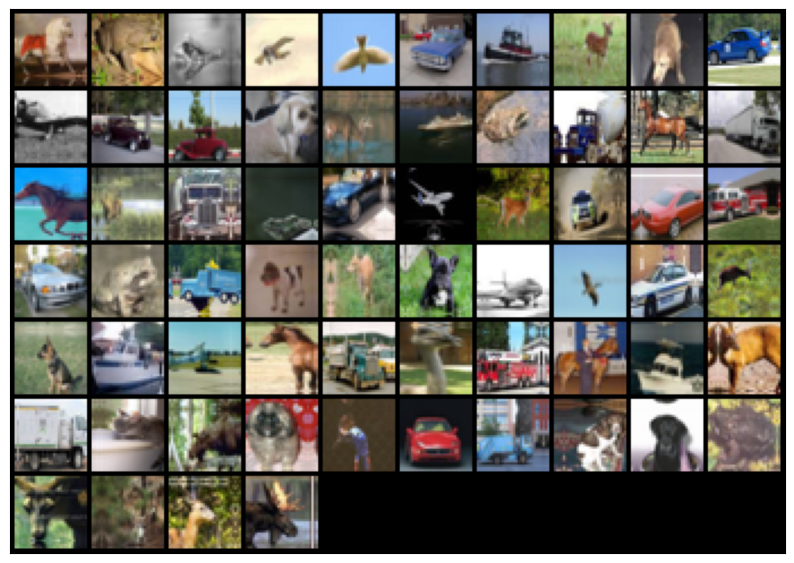

In [4]:
def denormalize(images, means, std_devs):
    dev = images.device
    means = torch.tensor(means).reshape(1, 3, 1, 1).to(dev)
    std_devs = torch.tensor(std_devs).reshape(1, 3, 1, 1).to(dev)
    return images * std_devs + means

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10, 10))
        images = denormalize(images, *data_statistics)
        grid = make_grid(images, nrow=10).cpu().permute(1, 2, 0)
        ax.imshow(grid)
        ax.set_xticks([])
        ax.set_yticks([])
        break

show_batch(train_dl)

## 5. Device Utilities
Helper functions and wrapper class to move data and models to GPU automatically.

In [5]:
def to_device(entity, device):
    if isinstance(entity, (list, tuple)):
        return [to_device(elem, device) for elem in entity]
    if hasattr(entity, 'to'):
        return entity.to(device, non_blocking=True)
    return entity

class DeviceDataLoader():
    """Wrapper around DataLoader to transfer batches to specified device."""
    def __init__(self, dataloader, device):
        self.dl = dataloader
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)
print(f"Data wrappers initialized on: {device}")

Data wrappers initialized on: cuda


## 6. Model Architecture — Baseline CNN
3 Convolutional layers followed by 2 Fully Connected layers with Dropout regularization.

| Layer | Details |
|-------|---------|
| Conv1 | 3 → 32 filters, 3x3 + BN + ReLU + MaxPool |
| Conv2 | 32 → 64 filters, 3x3 + BN + ReLU + MaxPool |
| Conv3 | 64 → 128 filters, 3x3 + BN + ReLU + MaxPool |
| FC1   | 2048 → 256 + Dropout(0.3) |
| FC2   | 256 → 10 (output) |

- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout
- **Activation:** ReLU
- **Regularization:** BatchNorm2d + Dropout

In [6]:
import torch.nn.functional as F
from collections import OrderedDict

class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def build_model():
    return BaseCNN()

model = to_device(build_model(), device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 620,810


## 7. Training Utilities
- `accuracy()` computes batch-level classification accuracy
- `evaluate()` runs the model in eval mode over a dataloader
- `train()` runs the full training loop with OneCycleLR scheduler and gradient clipping

In [7]:
def accuracy(logits, labels):
    _, predClassId = torch.max(logits, dim=1)
    return torch.tensor(torch.sum(predClassId == labels).item() / len(logits))

def evaluate(model, dl, loss_func):
    batch_losses, batch_accs = [], []
    model.eval()
    for images, labels in dl:
        with torch.no_grad():
            logits = model(images)
        batch_losses.append(loss_func(logits, labels))
        batch_accs.append(accuracy(logits, labels))
    epoch_avg_loss = torch.stack(batch_losses).mean().item()
    epoch_avg_acc = torch.stack(batch_accs).mean().item()
    return epoch_avg_loss, epoch_avg_acc

def train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim):
    optimizer = optim(model.parameters(), max_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(train_dl))

    results = []
    lrs = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for images, labels in train_dl:
            logits = model(images)
            loss = loss_func(logits, labels)
            train_losses.append(loss.detach())

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            optimizer.zero_grad()

            lrs.append(optimizer.param_groups[0]["lr"])
            scheduler.step()

        epoch_train_loss = torch.stack(train_losses).mean().item()

        model.eval()
        batch_losses, batch_accs = [], []
        for images, labels in val_dl:
            with torch.no_grad():
                logits = model(images)
            batch_losses.append(loss_func(logits, labels))
            batch_accs.append(accuracy(logits, labels))

        epoch_avg_loss = torch.stack(batch_losses).mean().item()
        epoch_avg_acc = torch.stack(batch_accs).mean().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_avg_loss:.4f} | Val Acc: {epoch_avg_acc:.4f}")

        results.append({
            'avg_valid_loss': epoch_avg_loss,
            'avg_valid_acc': epoch_avg_acc,
            'avg_train_loss': epoch_train_loss
        })

    return results, lrs

## 8. Training
Training Baseline CNN for 10 epochs using Adam optimizer with OneCycleLR scheduler and gradient clipping (max_norm=0.1).
Weight decay of 1e-4 applied for regularization.

In [8]:
epochs = 10
max_lr = 1e-2
loss_func = nn.functional.cross_entropy
optim = torch.optim.Adam

start_time = time.time()
results, lrs = train(model, train_dl, val_dl, epochs, max_lr, loss_func, optim)
end_time = time.time()

training_time = end_time - start_time
print(f"\nTraining complete. Training Time: {training_time:.2f} seconds")

Epoch [1/10] | Train Loss: 1.5037 | Val Loss: 1.4532 | Val Acc: 0.4971
Epoch [2/10] | Train Loss: 1.3826 | Val Loss: 1.6331 | Val Acc: 0.4374
Epoch [3/10] | Train Loss: 1.3901 | Val Loss: 1.6942 | Val Acc: 0.4351
Epoch [4/10] | Train Loss: 1.3472 | Val Loss: 1.4936 | Val Acc: 0.4808
Epoch [5/10] | Train Loss: 1.2936 | Val Loss: 1.5295 | Val Acc: 0.4870
Epoch [6/10] | Train Loss: 1.2164 | Val Loss: 1.2344 | Val Acc: 0.5652
Epoch [7/10] | Train Loss: 1.1267 | Val Loss: 1.1428 | Val Acc: 0.6011
Epoch [8/10] | Train Loss: 1.0336 | Val Loss: 0.9482 | Val Acc: 0.6614
Epoch [9/10] | Train Loss: 0.9325 | Val Loss: 0.8392 | Val Acc: 0.7095
Epoch [10/10] | Train Loss: 0.8676 | Val Loss: 0.8144 | Val Acc: 0.7155

Training complete. Training Time: 254.05 seconds


## 9. Training Curves
Plotting validation accuracy, train/val loss, and learning rate schedule across epochs.

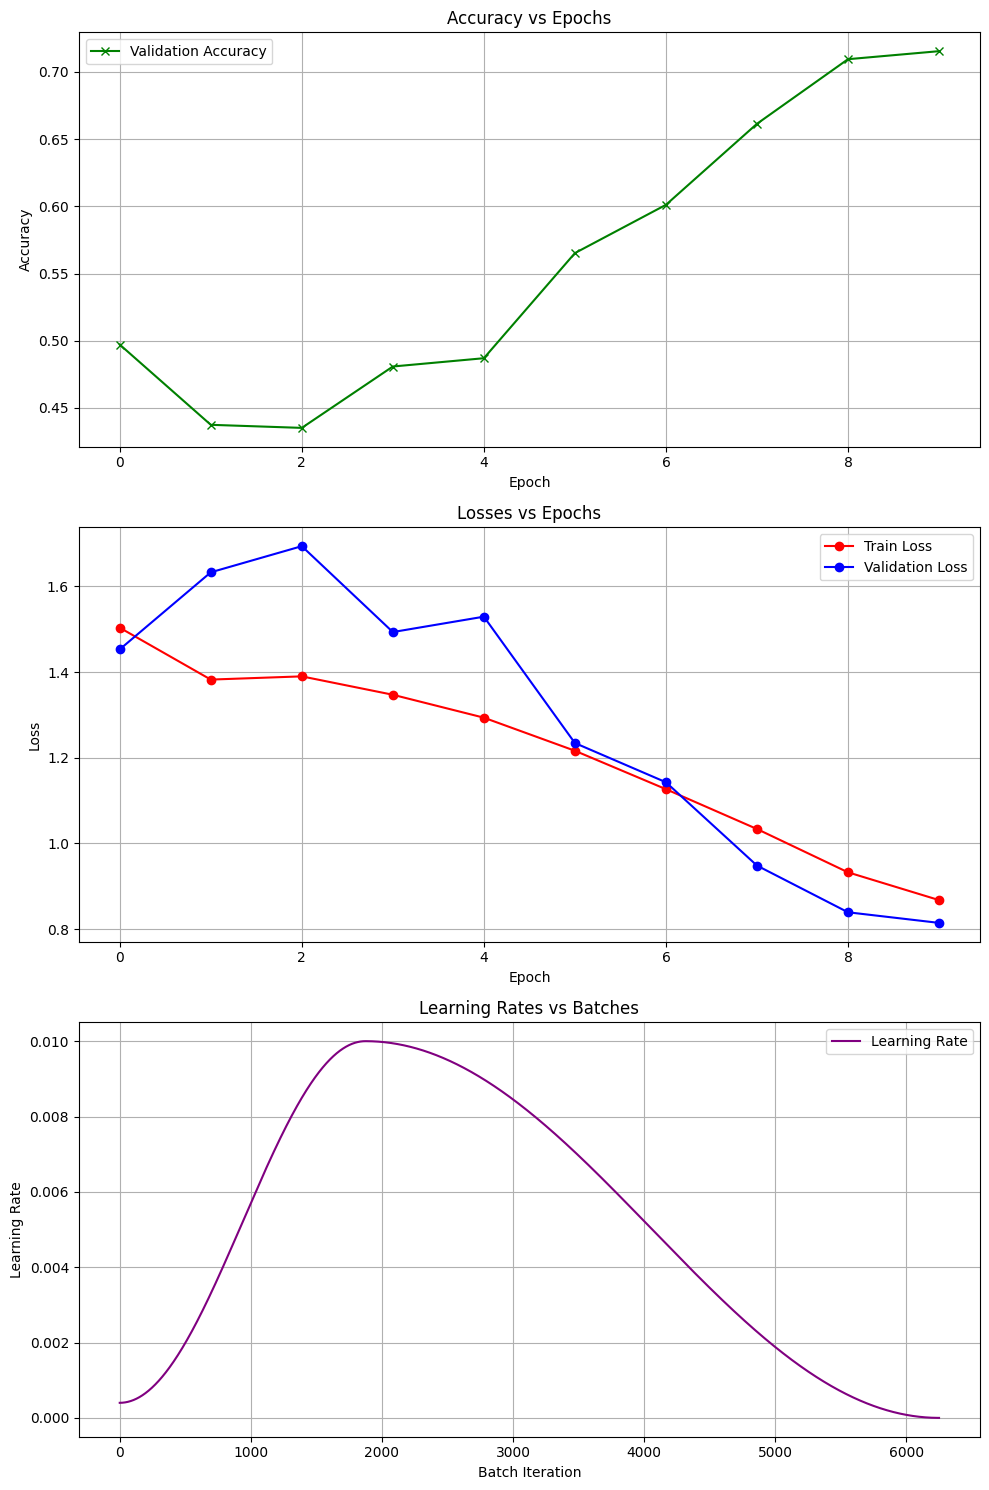

In [9]:
def plot_metrics(results, lrs):
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    val_accs = [r['avg_valid_acc'] for r in results]
    axes[0].plot(val_accs, '-x', color='green', label='Validation Accuracy')
    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    train_losses = [r['avg_train_loss'] for r in results]
    val_losses = [r['avg_valid_loss'] for r in results]
    axes[1].plot(train_losses, '-o', color='red', label='Train Loss')
    axes[1].plot(val_losses, '-o', color='blue', label='Validation Loss')
    axes[1].set_title('Losses vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(lrs, color='purple', label='Learning Rate')
    axes[2].set_title('Learning Rates vs Batches')
    axes[2].set_xlabel('Batch Iteration')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(results, lrs)

## 10. Saving and Evaluating the Model
Saving trained weights, then verifying the save/load pipeline by evaluating both the original and reloaded model.
Both should produce identical test accuracy.

In [10]:
_, test_acc = evaluate(model, test_dl, loss_func)
print(f"Original model test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), 'cifar10_baseline_cnn.pth')

# Reload and verify
model_reload = build_model()
model_reload = to_device(model_reload, device)
model_reload.load_state_dict(torch.load('cifar10_baseline_cnn.pth', weights_only=True))
_, test_acc2 = evaluate(model_reload, test_dl, loss_func)
print(f"Reloaded model test accuracy: {test_acc2:.4f}")

Original model test accuracy: 0.7416
Reloaded model test accuracy: 0.7416


## 11. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *74.16%* |
| Trainable Parameters | *620,810* |
| Training Time | *254.05 seconds(4.234 minutes)* |
| Hardware | GPU (Google Colab T4) |
| Epochs | 10 |
| Optimizer | Adam + OneCycleLR |

**Observation:** The Baseline CNN achieves 74% test accuracy on CIFAR-10 with 620,810 trainable parameters.

Validation accuracy shows instability in the early epochs (0-4) due to the OneCycleLR
warmup phase aggressively increasing the learning rate. From epoch 5 onward, accuracy
improves consistently, reaching 71.5% validation accuracy by epoch 9 with no signs of
overfitting.

The loss curves confirm this — validation loss rises initially while the learning rate
is at its peak, then drops steadily from epoch 5 onward, closely tracking train loss.
This indicates the model generalizes well with no significant overfitting gap.

The OneCycleLR schedule follows the expected cosine annealing pattern — learning rate
warms up to max_lr=0.01 around batch 2000, then anneals to near zero by batch 6250,
which corresponds to the stability seen in later epochs.

Further improvement expected with deeper architectures like ResNet18 and VGG11.